In [3]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

# Extract
with zipfile.ZipFile('/content/drive/MyDrive/mtcnn_splits.zip', 'r') as z:
    z.extractall('/content')

# Verify
for split in ['train', 'val', 'test']:
    split_dir = f'/content/data/mtcnn_splits/{split}'
    total = sum(len(os.listdir(os.path.join(split_dir, a)))
                for a in os.listdir(split_dir))
    print(f"{split}: {total} images, {len(os.listdir(split_dir))} actors")

Mounted at /content/drive
train: 16554 images, 100 actors
val: 3511 images, 100 actors
test: 3651 images, 100 actors


In [4]:
from google.colab import files
uploaded = files.upload()  # click "Choose Files" and select mtcnn_splits.zip

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
TRAIN_DIR   = '/content/data/mtcnn_splits/train'
VAL_DIR     = '/content/data/mtcnn_splits/val'
TEST_DIR    = '/content/data/mtcnn_splits/test'
SAVE_PATH   = '/content/drive/MyDrive/capstone_facerec/'
os.makedirs(SAVE_PATH, exist_ok=True)

IMG_SIZE    = (160, 160)
BATCH_SIZE  = 32
NUM_CLASSES = 100

In [10]:
def build_dataset(directory, augment=False):
    dataset = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=augment,
        seed=42
    )
    def preprocess(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        if augment:
            image = tf.image.random_flip_left_right(image)
            image = tf.image.random_brightness(image, 0.2)
            image = tf.image.random_contrast(image, 0.8, 1.2)
        return image, label
    return dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

train_ds = build_dataset(TRAIN_DIR, augment=True)
val_ds   = build_dataset(VAL_DIR,   augment=False)
test_ds  = build_dataset(TEST_DIR,  augment=False)

print("Train batches :", len(train_ds))
print("Val batches   :", len(val_ds))
print("Test batches  :", len(test_ds))

Found 16554 files belonging to 100 classes.
Found 3511 files belonging to 100 classes.
Found 3651 files belonging to 100 classes.
Train batches : 518
Val batches   : 110
Test batches  : 115


In [11]:
def build_model(trainable_base=False, unfreeze_layers=0):
    base = MobileNetV2(
        input_shape=(160, 160, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False
    if trainable_base and unfreeze_layers > 0:
        for layer in base.layers[-unfreeze_layers:]:
            layer.trainable = True

    inputs  = tf.keras.Input(shape=(160, 160, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return models.Model(inputs, outputs)

baseline_model = build_model(trainable_base=False)
baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)

trainable     = sum([tf.size(w).numpy() for w in baseline_model.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in baseline_model.non_trainable_weights])
print(f"Trainable     : {trainable:,}")
print(f"Non-trainable : {non_trainable:,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable     : 130,660
Non-trainable : 2,260,544


In [12]:
callbacks = [
    ModelCheckpoint(
        filepath=SAVE_PATH + 'baseline_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history_baseline = baseline_model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=callbacks
)


Epoch 1/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1029 - loss: 4.3892 - top5_accuracy: 0.2675
Epoch 1: val_accuracy improved from None to 0.30191, saving model to /content/drive/MyDrive/capstone_facerec/baseline_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/capstone_facerec/baseline_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 86s 114ms/step - accuracy: 0.1600 - loss: 3.8732 - top5_accuracy: 0.3729 - val_accuracy: 0.3019 - val_loss: 2.9608 - val_top5_accuracy: 0.5745 - learning_rate: 0.0010
Epoch 2/10
516/518 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3076 - loss: 2.8553 - top5_accuracy: 0.5967
Epoch 2: val_accuracy improved from 0.30191 to 0.35859, saving model to /content/drive/MyDrive/capstone_facerec/baseline_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/capstone_facerec/baseline_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.3117 - loss: 2.8248 - top5_accuracy: 0.6079 - val_accuracy: 0.3586 - val_l

In [13]:
def evaluate_model(model, dataset, name):
    results = model.evaluate(dataset, verbose=0)
    print(f"\n{name} Results:")
    print(f"  Loss          : {results[0]:.4f}")
    print(f"  Top-1 Accuracy: {results[1]*100:.2f}%")
    print(f"  Top-5 Accuracy: {results[2]*100:.2f}%")
    return results

baseline_mtcnn_results = evaluate_model(baseline_model, test_ds, "Baseline")


Baseline Results:
  Loss          : 2.3888
  Top-1 Accuracy: 42.51%
  Top-5 Accuracy: 71.41%


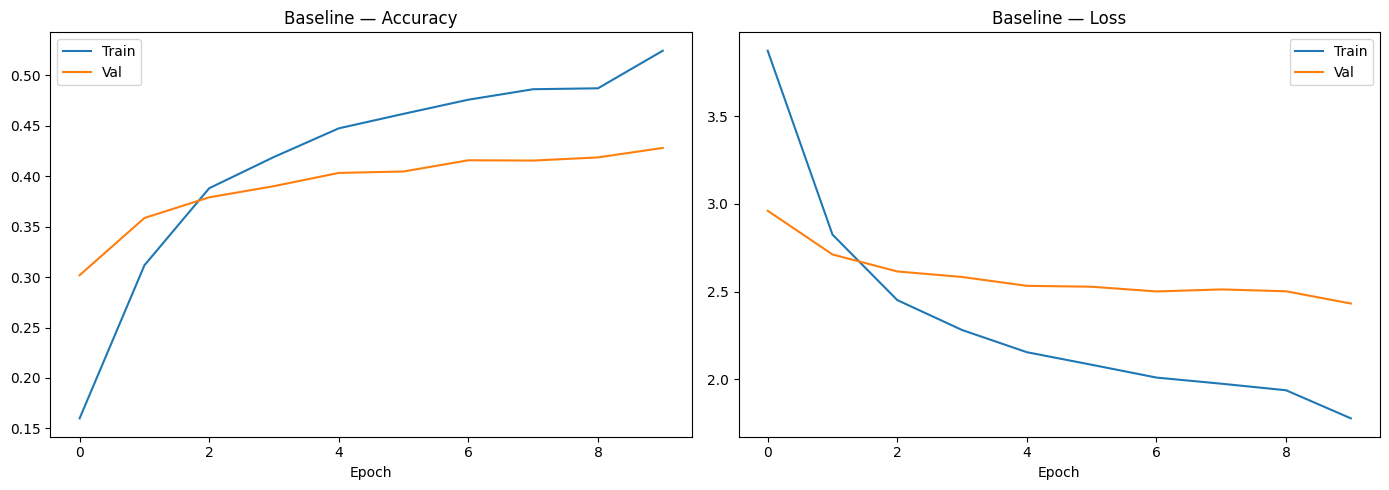

In [14]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(SAVE_PATH + f'{title}_curves.png', dpi=150)
    plt.show()

plot_history(history_baseline, 'Baseline')